# EMI — Étape 1 : corpus de témoignages écrits, annotation, classifieur de valence

**Objectif de l'étape** : construire un classifieur de valence/retentissement des expériences de conscience déconnectée à partir de récits écrits publics (NDERF, IANDS), réutilisable ensuite sur n'importe quel rappel libre (syncope, anesthésie, rêve).

**Plan du notebook**
0. Installation et configuration
1. Éthique : robots.txt et conditions d'utilisation
2. Reconnaissance de la structure des pages (à exécuter en premier, résultat à me montrer)
3. Collecte polie et mise en cache
4. Parsing → JSONL
5. Nettoyage (doublons, langue, longueur)
6. EDA du corpus et inventaire des champs structurés
7. Labels faibles (questionnaire + heuristiques)
8. Interface d'annotation manuelle (deux dimensions)
9. Classifieur : TF-IDF baseline vs embeddings multilingues
10. « Fightin' Words » : vocabulaire distinctif par classe, bigrammes, KWIC
11. Application au corpus entier et export
12. (optionnel) BERTopic

> Précaution : ces récits sont publics mais intimes. Corpus conservé en local, aucun extrait identifiable republié, aucune tentative de réidentification.

In [1]:
# 0. Installation (décommenter au premier run)
!pip install -q requests beautifulsoup4 lxml pandas numpy matplotlib seaborn scikit-learn sentence-transformers langdetect ipywidgets tqdm joblib

import os, re, json, time, hashlib, random, textwrap
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)
RNG = 42
random.seed(RNG); np.random.seed(RNG)

# --- Configuration ---
DATA = Path("data_emi"); DATA.mkdir(exist_ok=True)
CACHE = DATA / "html_cache"; CACHE.mkdir(exist_ok=True)
CORPUS_JSONL = DATA / "corpus_raw.jsonl"
CORPUS_CLEAN = DATA / "corpus_clean.parquet"
ANNOT_CSV = DATA / "annotations.csv"

BASE = "https://www.nderf.org"
# Index OBERF vérifiés (structure : entrées numérotées, lien, date, extrait, note éditoriale)
OBERF_INDEX = [
    "https://www.oberf.org/nde_like_stories.htm",     # NDE-Like (sans mort clinique : syncopes, anesthésie, rêves…)
    "https://www.oberf.org/ndelikethru2011.htm",      # NDE-Like archive 1999-2013
    # "https://www.oberf.org/ste.htm", "https://www.oberf.org/ste2013_2014.htm", ...   # STE, même format, si on élargit
]
# Archives NDERF anglaises : fichier nderf_archives_en.json (52 archives 1998-2026 + page courante) à placer dans data_emi/
ARCHIVES_JSON = DATA / "nderf_archives_en.json"
NDERF_INDEX, INDEX_META = [], {}
if ARCHIVES_JSON.exists():
    arch = json.loads(ARCHIVES_JSON.read_text(encoding="utf-8"))
    for a in arch["archives"] + [arch.get("current_page", {})]:
        if a.get("url"):
            NDERF_INDEX.append(a["url"])
            INDEX_META[a["url"]] = {"period_start": a.get("period_start"), "period_end": a.get("period_end"),
                                    "period_type": a.get("period_type"), "source_label": a.get("source_label")}
    print(f"{len(NDERF_INDEX)} index NDERF chargés depuis {ARCHIVES_JSON.name}")
else:
    print("nderf_archives_en.json absent de data_emi/ — seuls les index OBERF seront utilisés")
INDEX_URLS = OBERF_INDEX + NDERF_INDEX
# IANDS : https://iands.org/ndes/nde-stories/iands-nde-accounts.html (structure différente, à traiter ensuite)
HEADERS = {"User-Agent": "Exybris-research-bot/0.1 (academic, contact: exybrisai.com)"}
DELAY_S = 2.0   # politesse : un seul thread, 2 s entre requêtes
print("OK — dossiers :", DATA.resolve())

53 index NDERF chargés depuis nderf_archives_en.json
OK — dossiers : /Users/agltlm/Desktop/EMI EDA/data_emi


/Users/agltlm/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1. Éthique : robots.txt et conditions d'utilisation
On lit `robots.txt` et on l'affiche (NDERF n'en a pas : 404). **Conditions d'utilisation vérifiées** sur search.nderf.org : copyright conjoint NDERF + témoins ; usage autorisé *« exclusivement privé, personnel ou de recherche »* ; beaucoup de témoins n'autorisent **aucune** republication ailleurs que sur NDERF.

Conséquences pour nous : corpus en local, jamais partagé ni versionné publiquement ; aucun extrait verbatim dans une publication ou un dépôt ; seuls des résultats agrégés (fréquences, scores, modèles) sortent du projet. Un mail de courtoisie à Jody Long (webmaster) décrivant le projet est une bonne pratique avant toute diffusion de résultats.

In [2]:
def fetch(url, use_cache=True, timeout=30):
    key = hashlib.md5(url.encode()).hexdigest() + ".html"
    p = CACHE / key
    if use_cache and p.exists():
        return p.read_text(encoding="utf-8", errors="ignore")
    r = requests.get(url, headers=HEADERS, timeout=timeout)
    r.raise_for_status()
    r.encoding = r.apparent_encoding or "utf-8"
    p.write_text(r.text, encoding="utf-8")
    time.sleep(DELAY_S)
    return r.text

def absolutize(href, page_url):
    if href.startswith("http"): return href
    m = re.match(r"(https?://[^/]+)", page_url); host = m.group(1)
    if href.startswith("/"): return host + href
    return page_url.rsplit("/", 1)[0] + "/" + href

robots = requests.get(f"{BASE}/robots.txt", headers=HEADERS, timeout=30)
print(robots.status_code)
print(robots.text[:3000] if robots.ok else "(pas de robots.txt lisible)")

# Vérifie simplement si un Disallow couvre les préfixes qu'on compte visiter
disallows = [l.split(":",1)[1].strip() for l in robots.text.splitlines() if l.lower().startswith("disallow")] if robots.ok else []
for u in INDEX_URLS:
    path = u.replace(BASE, "")
    blocked = any(path.startswith(d) for d in disallows if d)
    print(f"{'BLOQUÉ ' if blocked else 'ok      '} {path}")

404
(pas de robots.txt lisible)
ok       https://www.oberf.org/nde_like_stories.htm
ok       https://www.oberf.org/ndelikethru2011.htm
ok       /Archives/2_1_2026.html
ok       /Archives/2_6_2025.html
ok       /Archives/2_1_2025.html
ok       /Archives/2_6_2024.html
ok       /Archives/2_1_2024.html
ok       /Archives/2_6_2023.html
ok       /Archives/2_1_2023.html
ok       /Archives/2_6_2022.html
ok       /Archives/2_1_2022.html
ok       /Archives/2_6_2021.html
ok       /Archives/2_1_2021.html
ok       /Archives/2_6_2020.html
ok       /Archives/2_1_2020.html
ok       /Archives/2_6_2019.html
ok       /Archives/2_1_2019.html
ok       /Archives/2_6_2018.html
ok       /Archives/2_1_2018.html
ok       /Archives/2_6_2017.html
ok       /Archives/2_1_2017.html
ok       /Archives/2_6_2016.html
ok       /Archives/2_1_2016.html
ok       /Archives/2_6_2015.html
ok       /Archives/2_1_2015.html
ok       /Archives/2_6_2014.html
ok       /Archives/2_1_2014.html
ok       /Archives/2_6_2013.html
ok     

## 2. Reconnaissance
Cette cellule ne collecte rien en masse : elle ouvre une page d'index et une page de récit, et affiche leur structure (titres, blocs de texte, questions détectées). **Copie-moi la sortie** : c'est avec ça qu'on calibre le parser.

In [3]:
def show_structure(url, n_preview=25):
    html = fetch(url)
    soup = BeautifulSoup(html, "lxml")
    print("=" * 80); print(url); print("TITLE:", soup.title.get_text(strip=True) if soup.title else None)
    print("\n-- Titres --")
    for h in soup.find_all(re.compile("^h[1-4]$"))[:15]:
        print(h.name, "|", h.get_text(" ", strip=True)[:120])
    print("\n-- Liens (échantillon) --")
    links = [a.get("href") for a in soup.find_all("a", href=True)]
    for l in links[:40]: print("  ", l)
    print(f"  ... {len(links)} liens au total")
    print("\n-- Blocs de texte les plus longs --")
    blocks = [(len(t.get_text(' ', strip=True)), t.name, t.get_text(' ', strip=True)) for t in soup.find_all(["p","div","td","span"])]
    blocks = sorted(blocks, reverse=True)[:8]
    for n, tag, txt in blocks: print(f"[{tag} {n} car.] {txt[:200]!r}")
    print("\n-- Lignes se terminant par '?' (questions du questionnaire ?) --")
    qs = [l.strip() for l in soup.get_text("\n").splitlines() if l.strip().endswith("?")]
    for q in qs[:n_preview]: print("  ", q[:140])
    print(f"  ... {len(qs)} questions détectées")
    return soup

# 2a. Découverte des index NDERF : on liste les liens de la page d'accueil qui ressemblent à des archives
home = BeautifulSoup(fetch(f"{BASE}/index.htm"), "lxml")
cands = sorted({a["href"] for a in home.find_all("a", href=True)
                if re.search(r"(rchive|nde|NDE|current|exceptional)", a["href"]) and a["href"].lower().endswith((".htm",".html"))})
print("Liens candidats (à copier dans INDEX_URLS s'ils pointent vers des listes de récits) :")
for c in cands: print("  ", c)

# 2b. Structure d'un index NDERF (si le JSON est chargé) — à comparer avec OBERF
if NDERF_INDEX:
    soup_nderf = show_structure(NDERF_INDEX[1])     # dernière archive close (2025-H2)
    nderf_links = [a["href"] for a in soup_nderf.find_all("a", href=True) if re.search(r"\.html?$", a["href"], re.I)]
    print("\nÉchantillon de liens de récit NDERF :", [l for l in nderf_links if "xperience" in l or "nde" in l.lower()][:8])

# 2c. Structure d'un index OBERF vérifié et d'un récit
soup_index = show_structure(INDEX_URLS[0])
cand = [a.get("href") for a in soup_index.find_all("a", href=True)
        if re.search(r"_(ndelike|nde|obe|ste|other|prayer)(_\d+)?\.htm$", a.get("href"), re.I)
        and not re.search(r"(stories|thru20|index)", a.get("href"), re.I)]
print("\nCandidats récit :", cand[:5])
if cand:
    soup_story = show_structure(absolutize(cand[0], INDEX_URLS[0]))

Liens candidats (à copier dans INDEX_URLS s'ils pointent vers des listes de récits) :
   https://www.nderf.org/Afrikaans/index_nde.htm
   https://www.nderf.org/Arabic/index_arabic.htm
   https://www.nderf.org/Basque/index_nde.htm
   https://www.nderf.org/Bulgarian/index_nde.htm
   https://www.nderf.org/Chinese/index_nde.htm
   https://www.nderf.org/ChineseSimple/index_nde.htm
   https://www.nderf.org/Croatian/index_nde.htm
   https://www.nderf.org/Czech/index_nde.htm
   https://www.nderf.org/Danish/index_nde.htm
   https://www.nderf.org/Dutch/index_nde.htm
   https://www.nderf.org/Finnish/index_nde.htm
   https://www.nderf.org/French/index_nde.htm
   https://www.nderf.org/German/index_nte.htm
   https://www.nderf.org/Greek/index_nde.htm
   https://www.nderf.org/Hebrew/index_nde.htm
   https://www.nderf.org/Hindi/index_nde.htm
   https://www.nderf.org/Hungarian/index_nde.htm
   https://www.nderf.org/Indonesian/index_nde.htm
   https://www.nderf.org/Italian/index_nde.htm
   https://www.n

## 3. Collecte
Collecte séquentielle, mise en cache disque : si tu relances, rien n'est re-téléchargé. Commence avec `MAX_PAGES` petit (50) pour valider, puis retire la limite.

Les deux regex ci-dessous (`LINK_RE`, `EXCLUDE_RE`) seront ajustées d'après la reconnaissance.

In [4]:
# Liens de récit OBERF : prenom_x_ndelike.htm, prenom_x_nde_21024.htm, prenom_x_obe.htm, prenom_x_ste.htm…
# OBERF : prenom_x_ndelike.htm, prenom_x_nde_21024.htm…  |  NDERF : /Experiences/…html (à confirmer via 2b)
LINK_RE = re.compile(r"(_(ndelike|nde|obe|sobe|ste|other|prayer|dream)(_\d+)?\.htm$|/Experiences/[^/]+\.html?$)", re.I)
def story_anchors(soup):
    # NDERF : les liens de récit portent la classe MiniLink (casse à respecter). Sinon (OBERF) : regex sur l'URL.
    mini = soup.select("a.MiniLink")
    if mini: return [a for a in mini if a.get("href")]
    return [a for a in soup.find_all("a", href=True) if LINK_RE.search(a["href"].strip()) and not EXCLUDE_RE.search(a["href"])]
EXCLUDE_RE = re.compile(r"(index|archive|stories|thru20|contact|donate|book|faq|privacy|search|share|disclaimer)", re.I)
MAX_PAGES = None        # mettre None pour tout prendre (≈ 5 000+ pages NDERF : compter quelques heures à DELAY_S=2, reprise possible)
# NDERF : catégorie + identifiant, d'abord depuis l'URL (/Experiences/robert_c_other_13426.htm), sinon depuis le texte
URL_CAT_RE = re.compile(r"_(probable_nde|possible_nde|not_nde|nde_like|ndelike|nde|other|obe|sobe|ste|adc|fde|dbv|nele)_?(\d{3,6})?\.html?$", re.I)
CAT_ID_RE = re.compile(r"\b(Probable NDE|Possible NDE|Not NDE|NDE-Like|NDE|Other|OBE|SOBE|STE|ADCs?|FDE|DBV)\s+(\d{3,6})\b")

from bs4 import NavigableString
DATE_RE = re.compile(r"\b(\d{1,2}/\d{1,2}/\d{2,4})\b")
def norm(t): return re.sub(r"\s+", " ", str(t).replace("\xa0", " ")).strip()

def parse_index_notes(index_url):
    # Entrées ancrées sur les liens de récit : le texte d'une entrée = tout ce qui suit son lien
    # jusqu'au lien suivant. Robuste au bruit (tabulations, entrées dans un seul <div>).
    soup = BeautifulSoup(fetch(index_url), "lxml")
    links = story_anchors(soup)
    notes, last_meta = {}, None
    for a, nxt in zip(links, links[1:] + [None]):
        parts = []
        for el in a.next_elements:
            if el is nxt: break
            if isinstance(el, NavigableString): parts.append(str(el))
        chunk = norm(" ".join(parts))
        chunk = re.split(r"Story Archives|Disclaimer/Terms", chunk)[0][:4000]
        chunk = re.sub(r"\s*\d{1,3}\.\s*$", "", chunk)      # numéro de l'entrée suivante
        prev = norm(a.find_previous(string=True) or "")
        m_num = re.search(r"(\d{1,3})\.\s*$", prev)
        m_date = DATE_RE.search(chunk)
        if not m_num and last_meta and len(chunk) < 200:      # 2e lien d'une même notice → mêmes métadonnées
            notes[absolutize(a["href"].strip(), index_url)] = {**last_meta, "multi_link": True}; continue
        m_url = URL_CAT_RE.search(a["href"]); m_cat = CAT_ID_RE.search(chunk)
        category = (m_url.group(1).replace("_", " ").upper().replace("PROBABLE NDE","Probable NDE").replace("POSSIBLE NDE","Possible NDE")
                    .replace("NDE LIKE","NDE-Like").replace("NDELIKE","NDE-Like").replace("OTHER","Other")) if m_url else (m_cat.group(1) if m_cat else None)
        nderf_id = int(m_url.group(2)) if (m_url and m_url.group(2)) else (int(m_cat.group(2)) if m_cat else None)
        notes[absolutize(a["href"].strip(), index_url)] = {
            "index_url": index_url, "source_site": re.sub(r"https?://(www\.)?", "", index_url).split("/")[0],
            "index_num": int(m_num.group(1)) if m_num else None,
            "index_name": norm(a.get_text()),
            "index_date": m_date.group(1) if m_date else None,
            "category": category, "nderf_id": nderf_id,
            "index_chunk": chunk,        # extrait + note éditoriale mêlés ; séparés au parsing du récit
            **INDEX_META.get(index_url, {}),
        }
        last_meta = notes[absolutize(a["href"].strip(), index_url)]
    return notes

def editorial_note(chunk, narrative, max_len=400):
    # L'extrait est copié du récit, la note éditoriale ne l'est pas :
    # on remonte depuis la fin du bloc et on garde les phrases absentes du récit.
    if not chunk: return ""
    nar = norm(narrative).lower()
    sents = re.split(r"(?<=[.!?])\s+", chunk)
    note = []
    for st in reversed(sents):
        key = re.sub(r"[^\w\s]", "", st.lower())[:40].strip()
        if len(key) > 15 and key in re.sub(r"[^\w\s]", "", nar): break
        note.insert(0, st)
    out = " ".join(note)
    return out if len(out) <= max_len else sents[-1]   # sécurité : si rien ne matche, dernière phrase seule

def collect_story_links(index_urls):
    found = []
    for iu in index_urls:
        try:
            soup = BeautifulSoup(fetch(iu), "lxml")
        except Exception as e:
            print("Index inaccessible :", iu, e); continue
        for a in story_anchors(soup):
            found.append(absolutize(a["href"].strip(), iu))
    found = list(dict.fromkeys(found))   # dédoublonne en gardant l'ordre
    print(f"{len(found)} liens de récits trouvés")
    return found

story_urls = collect_story_links(INDEX_URLS)
INDEX_NOTES = {}
for iu in INDEX_URLS:
    try: INDEX_NOTES.update(parse_index_notes(iu))
    except Exception as e: print("notes index :", iu, e)
print(f"{len(INDEX_NOTES)} notes éditoriales récupérées. Exemples :")
for u, n in list(INDEX_NOTES.items())[:5]: print("  ", n["index_num"], n["index_date"], "|", n["index_chunk"][-160:])
if MAX_PAGES: story_urls = story_urls[:MAX_PAGES]

for u in tqdm(story_urls, desc="Téléchargement"):
    try: fetch(u)
    except Exception as e: print("échec", u, e)
print("Pages en cache :", len(list(CACHE.glob('*.html'))))

6035 liens de récits trouvés
6035 notes éditoriales récupérées. Exemples :
   179 8/7/2026 | eir voices reached a peak of such greatness that even today I struggle to find words capable of describing it. Jesus looked toward me. NDE-like dream at age 12.
   178 7/19/2026 | t back to earth because the experience of love and peace was so profound. NDE vs anesthesia experience at age 15 associated with surgery. Shared 62 years later.
   177 12/23/2022 | ss and I was still me but completely alone. It felt like I was there forever, and I even had thoughts that I never really existed. NDE-like OBE void experience.
   176 5/3/2022 | cling the star. I didn't know anything about their lives, or who they were... but I KNEW them like I know myself. OBE dream with awareness of many other beings.
   175 4/6/2022 |  a long lost family someone who you love dearly, and they loved me, I felt that this place has always been my home. STE while in bed. Experience quite NDE-like.


Téléchargement:   0%|          | 0/6035 [00:00<?, ?it/s]

échec http://www.nderf.org/victor_z_sobe.htm 404 Client Error: Not Found for url: http://www.nderf.org/victor_z_sobe.htm
échec https://www.nderf.org/Experiences/victoria_p_probable_nde_13454.htm 404 Client Error: Not Found for url: https://www.nderf.org/Experiences/victoria_p_probable_nde_13454.htm
échec https://www.nderf.org/Experiences/kris_nde_13450.htm 404 Client Error: Not Found for url: https://www.nderf.org/Experiences/kris_nde_13450.htm
échec https://www.nderf.org/Experiences/mary_j_neles_13317.htm 404 Client Error: Not Found for url: https://www.nderf.org/Experiences/mary_j_neles_13317.htm
échec https://www.nderf.org/Experiences/izzy_p_probable_nde_13267.htm 404 Client Error: Not Found for url: https://www.nderf.org/Experiences/izzy_p_probable_nde_13267.htm
échec https://www.nderf.org/Experiences/1wayne_h_nde_13260.htm 404 Client Error: Not Found for url: https://www.nderf.org/Experiences/1wayne_h_nde_13260.htm
échec https://www.nderf.org/Experiences/1elenilda_s_nde_13257.htm 

## 4. Parsing → JSONL (v3, DOM, d'après le guide d'audit du 14/09)
Deux familles de balisage sur les pages individuelles NDERF :
- **classes** : section `.m108`, question/libellé `.m105` ;
- **styles inline** : section en `#0080FF`, question en `#009999`.

Règle : on parcourt le DOM dans l'ordre ; un marqueur de section met à jour la section courante ; la **réponse** à un libellé = tout le texte entre la fin du libellé et le marqueur suivant. Le **récit** = le texte de la section « Experience Description » avant le premier libellé. Les items sont gardés en liste ordonnée (libellés répétés possibles). Pages sans marqueur → repli texte, avec alerte. Tout est lu depuis le cache.

In [5]:
# 4a. Diagnostic : familles de balisage présentes dans le cache
from bs4 import NavigableString, Tag
Q_CLASSES, S_CLASSES = {"m105"}, {"m108"}
Q_COLORS, S_COLORS = ("#009999", "rgb(0,153,153)"), ("#0080ff", "rgb(0,128,255)")

def marker_role(tag):
    if not isinstance(tag, Tag): return None
    cls = {c.lower() for c in (tag.get("class") or [])}
    if tag.name in ("h1", "h2", "h3", "h4", "h5") and (SECTION_NAMES_RE.match(norm(tag.get_text(" "))) or "color_blue" in cls): return "s"
    if cls & Q_CLASSES: return "q"
    if cls & S_CLASSES: return "s"
    style = ((tag.get("style") or "") + " " + (tag.get("color") or "")).lower().replace(" ", "")
    if any(c in style for c in Q_COLORS): return "q"
    if any(c in style for c in S_COLORS): return "s"
    return None

SECTION_NAMES_RE = re.compile(r"^(experience description|background information|nde elements|god, spiritual and religion|"
                              r"concerning our earthly lives other than religion|after the nde|description of (the )?experience)\s*:?\s*$", re.I)
def content_root(soup):
    # La zone de contenu est celle qui contient réellement « Experience Description » ; le 1er div.container est souvent le menu.
    # ATTENTION : HTML NDERF malformé → lxml emboîte le contenu DANS le <nav> du menu. Ne jamais supprimer nav/header/footer ici.
    for t in soup(["script", "style", "head", "iframe", "video"]): t.decompose()
    cands = soup.select("section.section_offset, main, article, div.container")
    cands = [c for c in cands if re.search(r"experience\s+description|description of (the )?experience", c.get_text(" "), re.I)]
    if cands: return min(cands, key=lambda c: len(c.get_text(" ")))     # le plus petit conteneur qui contient le récit
    return soup.body or soup

def page_family(url):
    soup = BeautifulSoup(fetch(url), "lxml"); root = content_root(soup)
    roles = Counter(marker_role(t) for t in root.find_all(True)); roles.pop(None, None)
    cls = any((t.get("class") and set(c.lower() for c in t["class"]) & (Q_CLASSES | S_CLASSES)) for t in root.find_all(True))
    return ("classes" if cls else "couleurs" if roles else "sans_marqueurs"), roles.get("q", 0), roles.get("s", 0)

sample = random.Random(RNG).sample(story_urls, min(60, len(story_urls)))
fam = pd.DataFrame([(u, *page_family(u)) for u in tqdm(sample, desc="Diagnostic")], columns=["url", "famille", "n_q", "n_s"])
print(fam.famille.value_counts()); display(fam.groupby("famille")[["n_q", "n_s"]].median())

Diagnostic:   0%|          | 0/60 [00:00<?, ?it/s]

famille
couleurs    35
classes     25
Name: count, dtype: int64


,n_q,n_s
famille,,
classes,55.0,6.0
couleurs,51.0,6.0


In [6]:
# 4b. Parseur DOM
BLOCK_TAGS = {"p", "div", "br", "li", "tr", "h1", "h2", "h3", "h4", "table", "section", "blockquote"}
SECTION_NARR_RE = re.compile(r"(experience description|description of (the )?experience|description de l.exp|descrizione)", re.I)
EDITORIAL_RE = re.compile(r"\bNDERF (responds|response|comment)s?\s*:", re.I)

def segments(root):
    # Liste ordonnée de [role, marker_id, texte] ; role ∈ {'q','s',None}. Les blocs ajoutent un saut de ligne.
    out = []
    def rec(node, role, mid):
        for ch in node.children:
            if isinstance(ch, NavigableString):
                if ch.parent.name in ("script", "style"): continue
                t = str(ch)
                if t.strip(): out.append([role, mid, t])
            elif isinstance(ch, Tag):
                if ch.name in ("script", "style", "iframe", "video", "img"): continue
                r = marker_role(ch)
                if ch.name in BLOCK_TAGS: out.append([None, None, "\n"])
                rec(ch, r or role, id(ch) if r else mid)
                if ch.name in BLOCK_TAGS: out.append([None, None, "\n"])
    rec(root, None, None)
    merged = []
    for role, mid, t in out:
        if merged and role is not None and merged[-1][0] == role and merged[-1][1] == mid: merged[-1][2] += t
        else: merged.append([role, mid, t])
    return merged

def parse_story_v3(url):
    soup = BeautifulSoup(fetch(url), "lxml")
    title = soup.title.get_text(strip=True) if soup.title else ""
    root = content_root(soup)
    segs = segments(root)
    items, warnings, narrative_parts, pre_parts, editorial_parts = [], [], [], [], []
    section, cur, n_narr_sections, in_editorial = None, None, 0, False
    for role, mid, t in segs:
        tt = norm(t)
        if role == "s":
            if tt:
                section, cur, in_editorial = tt, None, False
                if SECTION_NARR_RE.search(tt): n_narr_sections += 1
        elif role == "q":
            if tt:
                cur = {"section": section, "order": len(items), "question": tt, "answer": ""}; items.append(cur)
        else:
            if cur is not None: cur["answer"] += t
            elif section and SECTION_NARR_RE.search(section):
                if EDITORIAL_RE.search(t): in_editorial = True; warnings.append("editorial_in_narrative")
                (editorial_parts if in_editorial else narrative_parts).append(t)
            else: pre_parts.append(t)
    TRAILER_RE = re.compile(r"(Copyright|©|All rights reserved|Share Your Experience|Back to Top|Home\s+Share|NDERF Home)", re.I)
    for it in items: it["answer"] = norm(it["answer"])[:3000]
    if items:
        it = items[-1]; m = TRAILER_RE.search(it["answer"])
        if m: it["answer"] = it["answer"][:m.start()].strip(); warnings.append("pied_de_page_coupe")
    narrative = norm("".join(narrative_parts))
    if not items:
        m = TRAILER_RE.search(narrative)
        if m: narrative = narrative[:m.start()].strip()
    family = "dom"
    if not items and not narrative:               # repli texte : pages sans marqueurs
        family = "texte"; warnings.append("sans_marqueurs")
        txt = norm(root.get_text(" "))
        m = NARR_START_RE.search(txt)
        narrative = txt[m.end():][:20000] if m else ""
        if not m: warnings.append("recit_introuvable")
    if n_narr_sections > 1: warnings.append(f"{n_narr_sections}_sections_recit")
    if not narrative: warnings.append("recit_vide")
    qa = {}
    for it in items:                               # première occurrence de chaque libellé → colonnes ; la liste complète reste dans items
        qa.setdefault(it["question"], it["answer"])
    rec = {"url": url, "title": title, "narrative": narrative, "n_chars": len(narrative), "family": family,
           "qa": qa, "items": items, "n_q": len(items), "editorial": norm("".join(editorial_parts))[:3000],
           "warnings": warnings, "raw_text": norm(root.get_text(" "))[:60000]}
    rec.update(INDEX_NOTES.get(url, {}))
    rec["index_note"] = editorial_note(rec.get("index_chunk", ""), narrative)
    return rec

NARR_START_RE = re.compile(r"(Experience description|Description of (the )?experience|Description de l.exp[ée]rience)\s*:?\s*", re.I)
r_test = parse_story_v3(story_urls[0])
print(r_test["title"], "|", r_test["family"], "|", r_test["n_chars"], "car. |", r_test["n_q"], "items |", r_test["warnings"])
print(r_test["narrative"][:400]); print(r_test["items"][:4])

Edwin W NDE-Like 21025 | dom | 3927 car. | 29 items | []
Heaven's Stairs - My Experience at Twelve My name is Edwin W. I was approximately twelve years old when I had an experience that has remained extraordinarily vivid throughout my life. Many years later, as an adult, I was diagnosed with Autism Spectrum Disorder. This was not something I experienced during a known medical emergency. I experienced myself leaving my body and beginning an incredible jo
[{'section': 'Experience description:', 'order': 0, 'question': 'Any associated medications or substances with the potential to affect the experience?', 'answer': 'No'}, {'section': 'Experience description:', 'order': 1, 'question': 'Was the kind of experience difficult to express in words?', 'answer': "Yes Parts of the experience, especially the angels' singing, the light, the distances traveled, and the emotions, are extremely difficult to put into words."}, {'section': 'Experience description:', 'order': 2, 'question': 'At the time o

In [7]:
# 4c. Parsing complet + bilan
records, failed = [], []
for u in tqdm(story_urls, desc="Parsing v3"):
    try: records.append(parse_story_v3(u))
    except Exception as e: failed.append((u, str(e)[:100]))
print(f"{len(records)} récits parsés, {len(failed)} échecs")
with open(CORPUS_JSONL, "w", encoding="utf-8") as f:
    for r in records: f.write(json.dumps(r, ensure_ascii=False) + "\n")

bilan = pd.DataFrame([{"site": re.sub(r"https?://(www\.)?", "", r["url"]).split("/")[0], "family": r["family"],
                       "n_chars": r["n_chars"], "n_q": r["n_q"], "warn": ";".join(r["warnings"])} for r in records])
print("\nRécits ≥ 300 car. par site :"); display(bilan.assign(ok=bilan.n_chars >= 300).groupby("site").ok.agg(["sum", "count"]))
print("Famille :"); display(bilan.groupby(["site", "family"]).size())
print("Alertes :"); display(bilan.warn.str.split(";").explode().value_counts())
print("Items/page (médiane) :", bilan.n_q.median(), "| car. récit (médiane) :", bilan.n_chars.median())

QA_KEYS = Counter(k for r in records for k in r["qa"])
print(f"\n{len(QA_KEYS)} libellés distincts. Les plus fréquents :")
for q, n in QA_KEYS.most_common(40): print(f"  {n:5d}  {q[:110]}")
print("\n-- Notes éditoriales (contrôle) --")
for r in records[:8]: print(f"  [{r.get('index_num')}] {r.get('index_note','')[:120]}")

Parsing v3:   0%|          | 0/6035 [00:00<?, ?it/s]

6021 récits parsés, 14 échecs

Récits ≥ 300 car. par site :


,sum,count
site,,
nderf.org,5743,5852
oberf.org,153,169


Famille :


site       family
nderf.org  dom       5849
           texte        3
oberf.org  dom        147
           texte       22
dtype: int64

Alertes :


warn
                          5854
2_sections_recit           114
recit_vide                  28
sans_marqueurs              25
3_sections_recit            11
recit_introuvable            5
pied_de_page_coupe           3
editorial_in_narrative       3
4_sections_recit             1
Name: count, dtype: int64

Items/page (médiane) : 52.0 | car. récit (médiane) : 2222.0

420 libellés distincts. Les plus fréquents :
   5663  Gender:
   5603  At the time of your experience, was there an associated life-threatening event?
   5574  Have you ever shared this experience with others?
   5569  Was the experience difficult to express in words?
   5561  Did you feel separated from your body?
   5532  Do you have any psychic, non-ordinary or other special gifts after your experience that you did not have befor
   5532  Did you have a change in your values and beliefs because of your experience?
   5525  How do you consider the content of your experience?
   5522  Did time seem to speed up or slow down?
   5514  Did you pass into or through a tunnel?
   5474  At any time in your life, has anything ever reproduced any part of the experience?
   5470  Did you see an unearthly light?
   5432  Did you come to a border or point of no return?
   5344  What was your religion prior to your experience?
   5314  W

## 5. Nettoyage
Doublons (hash du récit), langue (`langdetect`), longueur minimale, séparation FR/EN.

In [8]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = RNG

df = pd.DataFrame(records)
print("Avant filtre :", len(df))
df = df[df.n_chars >= 300].copy()
print("Après filtre ≥ 300 car. :", len(df))
df["hash"] = df.narrative.str.lower().str.replace(r"\s+"," ",regex=True).map(lambda s: hashlib.md5(s.encode()).hexdigest())
before = len(df); df = df.drop_duplicates("hash"); print(f"Doublons retirés : {before-len(df)}")

def safe_lang(s):
    try: return detect(s[:2000])
    except Exception: return "unk"
df["lang"] = df.narrative.map(safe_lang)
print(df.lang.value_counts())

# Explose le questionnaire en colonnes (une par question), utile pour l'inventaire
KEEP_Q = [q for q, n in QA_KEYS.items() if n >= 20]      # libellés présents sur ≥ 20 pages
qa_df = pd.DataFrame([{q: r.get(q) for q in KEEP_Q} for r in df["qa"]], index=df.index)
df_full = pd.concat([df.drop(columns=["qa", "items"]), qa_df], axis=1)
print(f"{len(KEEP_Q)} libellés conservés en colonnes")

# Colonnes unifiées (multilingues) : première question dont l'intitulé matche le motif
UNIFIED = {
    "self_valence": r"^how do you consider the content of your experience|^come considera il contenuto|^comment consid",
    "emo_during":   r"(emotions? .*during|émotions? .*pendant|emozioni .*durante|emociones .*durante)",
    "emo_after":    r"(emotions? .*(following|after)|émotions? .*(après|suite)|emozioni .*dopo|emociones .*después)",
    "life_threat":  r"(life[- ]threatening|mise en danger|pericolo di vita|amenaza)",
    "substances":   r"(medications or substances|médicaments|farmaci|medicamentos)",
    "dreamlike":    r"(dream like|onirique|sogno|sueño)",
    "separation":   r"(separat(ed|ion) .*body|séparation de votre conscience|separato dal corpo)",
    "gender":       r"^gender:|^genere:|^sexe",
    "date_nde":     r"^date nde occurred|^data in cui",
    "religion_before": r"religion prior to your experience",
    "fear_before":  r"fear death prior|peur de la mort avant",
    "fear_after":   r"fear death after|peur de la mort après",
    "knew_nde":     r"knowledge of near death experience \(nde\) prior",
    # Items Greyson (échelle 16 items : cognitif, affectif, paranormal, transcendantal)
    "g_time":       r"^did time seem to speed up",
    "g_thoughts":   r"^were your thoughts speeded up",
    "g_past":       r"^did scenes from your past",
    "g_understand": r"^did you suddenly seem to understand everything",
    "g_peace":      r"^did you have a feeling of peace",
    "g_joy":        r"^did you have a feeling of joy",
    "g_harmony":    r"^did you feel a sense of harmony or unity",
    "g_light":      r"^did you see, or feel surrounded by, a brilliant light",
    "g_senses":     r"^were your senses more vivid",
    "g_aware_elsewhere": r"^did you seem to be aware of things going on elsewhere",
    "g_future":     r"^did scenes from the future",
    "g_oob":        r"^did you feel separated from your body",
    "g_other_world": r"^did you seem to enter some other, unearthly world",
    "g_mystical":   r"^did you seem to encounter a mystical being or presence",
    "g_deceased":   r"^did you see deceased or religious spirits",
    "g_border":     r"^did you come to a border or point of no return",
}
for col, pat in UNIFIED.items():
    qs = [c for c in KEEP_Q if re.search(pat, c, re.I)]
    df_full[col] = df_full[qs].bfill(axis=1).iloc[:, 0] if qs else None
    print(f"{col:18} ← {len(qs)} libellé(s), rempli pour {df_full[col].notna().sum()} récits")

# Valence auto-déclarée normalisée — réponses fermées réelles de NDERF (voir value_counts ci-dessous)
def norm_valence(v):
    if not isinstance(v, str): return None
    h = v.strip().lower()
    if h.startswith(("entirely pleasant", "wonderful", "positive", "pleasant")): return "positive"
    if h.startswith(("mixed", "both pleasant", "both ", "mixte", "mista", "mixta")): return "mixte"
    if h.startswith(("neither pleasant", "neutral", "neither")): return "neutre"
    if h.startswith(("entirely distressing", "entirely unpleasant", "frightening", "disturbing", "negative", "distressing", "unpleasant", "hellish")): return "negative"
    return "autre"
df_full["self_valence_norm"] = df_full["self_valence"].map(norm_valence)
print("\nValence auto-déclarée :"); print(df_full["self_valence_norm"].value_counts(dropna=False))
print("Valeurs brutes restées en 'autre' :"); print(df_full.loc[df_full.self_valence_norm == "autre", "self_valence"].str[:40].value_counts().head(8))

# Score de Greyson (1983) reconstruit : NDERF utilise les options de réponse originales (2 / 1 / 0 par item).
# Libellés restitués de mémoire — la couverture par item ci-dessous sert de contrôle.
GREYSON = {
    "g_time":       (("everything seemed to be happening at once",), ("time seemed to go faster or slower",)),
    "g_thoughts":   (("incredibly fast",), ("faster than usual",)),
    "g_past":       (("my past flashed before me",), ("i remembered many past events",)),
    "g_understand": (("everything about the universe",), ("everything about myself or others",)),
    "g_peace":      (("incredible peace",), ("relief or calmness",)),
    "g_joy":        (("incredible joy",), ("happiness",)),
    "g_harmony":    (("i felt united or one with the world",), ("i felt no longer in conflict with nature",)),
    "g_light":      (("a light clearly of mystical",), ("an unusually bright light",)),
    "g_senses":     (("incredibly more vivid",), ("more vivid than usual",)),
    "g_aware_elsewhere": (("yes, and the facts have been checked",), ("yes, but the facts have not been checked",)),
    "g_future":     (("scenes from the world's future", "scenes from the worlds future"), ("scenes from my personal future",)),
    "g_oob":        (("i clearly left my body",), ("i lost awareness of my body",)),
    "g_other_world": (("a clearly mystical or unearthly realm",), ("some unfamiliar and strange place",)),
    "g_mystical":   (("definite being, or voice clearly of mystical", "a definite being"), ("i heard a voice i could not identify",)),
    "g_deceased":   (("i saw them", "i actually saw them"), ("i sensed their presence",)),
    "g_border":     (("a barrier i was not permitted to cross", "sent back"), ("a conscious decision to",)),
}
def g_score(v, keys2, keys1):
    if not isinstance(v, str): return np.nan
    h = v.strip().lower()
    if any(k in h[:80] for k in keys2): return 2.0
    if any(k in h[:80] for k in keys1): return 1.0
    if h.startswith(("no", "uncertain", "not sure", "none")): return 0.0
    return np.nan          # texte libre (anciennes versions du questionnaire) : non cotable
G = pd.DataFrame({c: df_full[c].map(lambda v: g_score(v, *GREYSON[c])) for c in GREYSON})
df_full["greyson_n_scored"] = G.notna().sum(axis=1)
df_full["greyson_score"] = G.sum(axis=1).where(df_full["greyson_n_scored"] >= 14)     # score sur 32 si ≥ 14 items cotables
df_full["greyson_nde"] = df_full["greyson_score"] >= 7
print("\nCouverture des items Greyson (part des réponses cotables parmi les renseignées) :")
print((G.notna().sum() / df_full[list(GREYSON)].notna().sum()).round(2).to_string())
print("\nScore Greyson (0–32) disponible pour", df_full["greyson_score"].notna().sum(), "récits ; ≥ 7 (seuil EMI) :", int(df_full["greyson_nde"].sum()))
df_full.to_parquet(CORPUS_CLEAN)
print(df_full.shape, "→", CORPUS_CLEAN)

Avant filtre : 6021
Après filtre ≥ 300 car. : 5896
Doublons retirés : 3
lang
en    5892
bg       1
Name: count, dtype: int64
94 libellés conservés en colonnes
self_valence       ← 1 libellé(s), rempli pour 5424 récits
emo_during         ← 1 libellé(s), rempli pour 5214 récits
emo_after          ← 0 libellé(s), rempli pour 0 récits
life_threat        ← 1 libellé(s), rempli pour 5497 récits
substances         ← 0 libellé(s), rempli pour 0 récits
dreamlike          ← 0 libellé(s), rempli pour 0 récits
separation         ← 1 libellé(s), rempli pour 5459 récits
gender             ← 1 libellé(s), rempli pour 5557 récits
date_nde           ← 1 libellé(s), rempli pour 5125 récits
religion_before    ← 1 libellé(s), rempli pour 5247 récits
fear_before        ← 1 libellé(s), rempli pour 1428 récits
fear_after         ← 1 libellé(s), rempli pour 1427 récits
knew_nde           ← 1 libellé(s), rempli pour 4740 récits
g_time             ← 1 libellé(s), rempli pour 5418 récits
g_thoughts         ← 1 l

## 6. EDA
Longueurs, langues, et surtout **inventaire des champs structurés** : quelles questions reviennent, et lesquelles parlent d'émotion / valence. Ce sont nos futurs labels faibles.

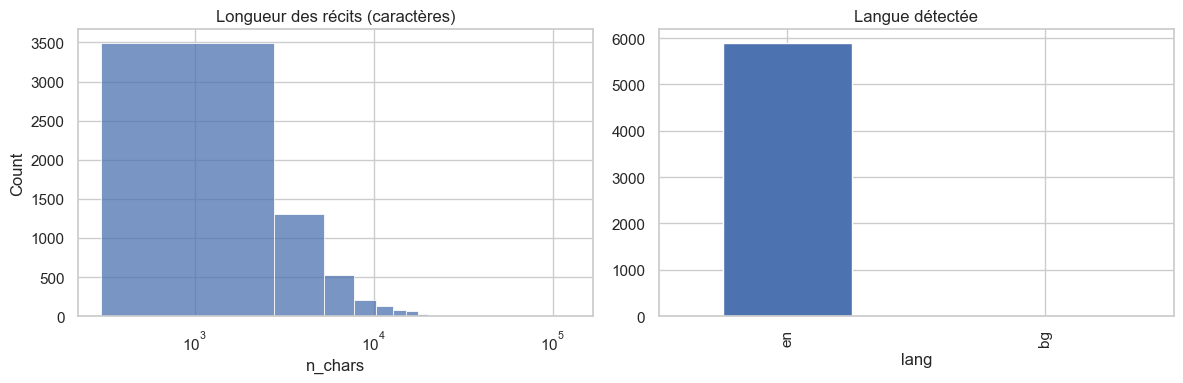

source_site,nderf.org,oberf.org
category,,
?,124,1
ADC,31,0
ADCs,1,0
DBV,5,0
FDE,138,0
NDE,4128,4
NDE-Like,53,131
NELE,3,0
OBE,11,7


94 questions distinctes. Les plus fréquentes :


,couverture
Gender:,0.942983
"At the time of your experience, was there an associated life-threatening event?",0.932802
Have you ever shared this experience with others?,0.928729
Was the experience difficult to express in words?,0.927371
Did you feel separated from your body?,0.926353
Did you have a change in your values and beliefs because of your experience?,0.921602
"Do you have any psychic, non-ordinary or other special gifts after your experience that you did not have before the experience?",0.921093
How do you consider the content of your experience?,0.920414
Did time seem to speed up or slow down?,0.919396
Did you pass into or through a tunnel?,0.918378



Valence auto-déclarée × catégorie :


self_valence_norm,autre,mixte,negative,neutre,positive,—
category,,,,,,
?,2,37,4,8,54,20
ADC,0,11,0,3,14,3
ADCs,0,0,0,1,0,0
DBV,0,0,0,0,3,2
FDE,1,44,14,16,60,3
NDE,10,1161,166,203,2342,250
NDE-Like,1,13,1,3,33,133
NELE,0,1,0,0,1,1
OBE,0,1,2,2,6,7


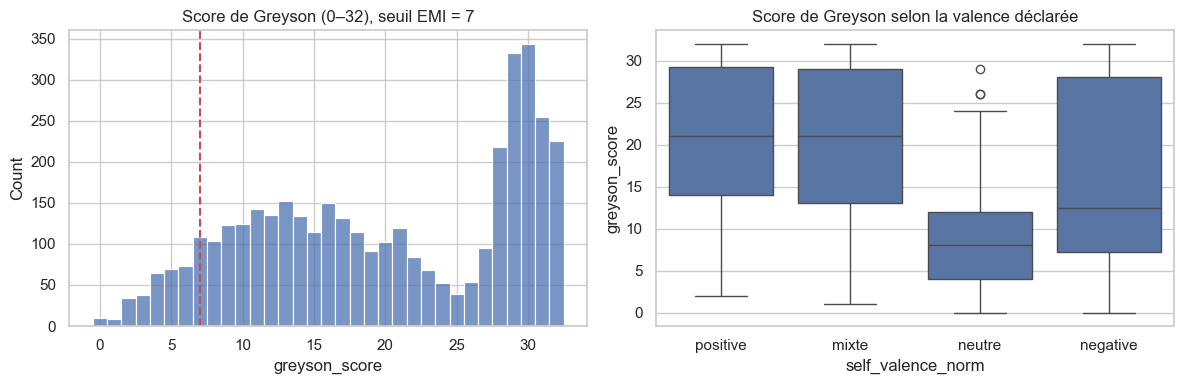

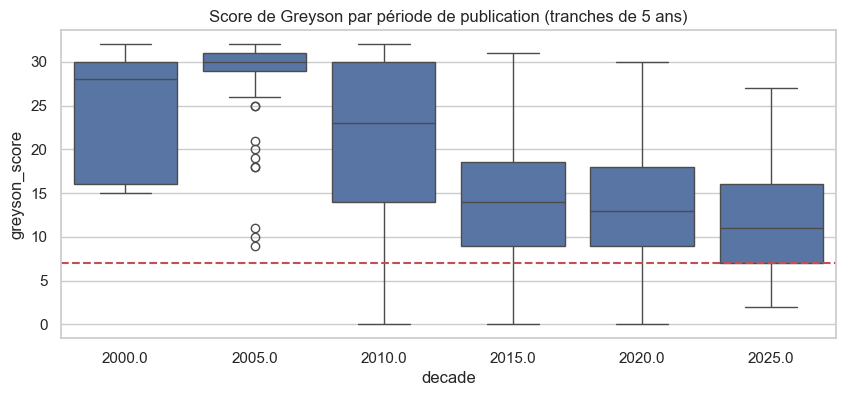

decade,1995.0,2000.0,2005.0,2010.0,2015.0,2020.0,2025.0
count,0.0,8.0,718.0,1581.0,815.0,726.0,62.0
median,NaN,28.0,30.0,23.0,14.0,13.0,11.0



Aperçu des réponses émotion (unifiées) :
- emo_during


,emo_during
2145,"I felt excitement at watching my schoolmates playing, it was like watching a normal soccer game. I didn't feel peace..."
1066,"Before the lady entered the room I felt nervousness, some fear, unease. After she came in I felt extremely calm, cen..."
4876,"Calm that there is more than what we live, fear of unknown, fear of leaving without saying goodbye, love from my dec..."
5547,"Peace, warmth, fulfillment, never loneliness. Happiness. And someone next to me giving unconditional love."
1827,"I felt Ecstasy, Bliss, Unconditional Love and no fear, whatsoever."
4094,I was just so overjoyed and I felt such peace.
1082,I felt safe. very safe.
1506,Happy
1378,"I felt an 'aw sh#$t,' moment because something went wrong with the surgery."
1353,"The emotions I felt or peace so much deep loving peace, love, and joy. I felt emotions that I still can't find words..."


- emo_after


,emo_after


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_full.n_chars, bins=50, ax=ax[0]); ax[0].set_title("Longueur des récits (caractères)"); ax[0].set_xscale("log")
df_full.lang.value_counts().plot.bar(ax=ax[1]); ax[1].set_title("Langue détectée")
plt.tight_layout(); plt.show()

if "category" in df_full: display(pd.crosstab(df_full["category"].fillna("?"), df_full["source_site"].fillna("?")))
qa_cols = KEEP_Q
coverage = df_full[qa_cols].notna().mean().sort_values(ascending=False)
print(f"{len(qa_cols)} questions distinctes. Les plus fréquentes :")
display(coverage.head(40).to_frame("couverture"))

print("\nValence auto-déclarée × catégorie :")
display(pd.crosstab(df_full["category"].fillna("?"), df_full["self_valence_norm"].fillna("—")))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_full["greyson_score"].dropna(), bins=33, discrete=True, ax=ax[0]); ax[0].axvline(7, color="r", ls="--"); ax[0].set_title("Score de Greyson (0–32), seuil EMI = 7")
order = ["positive", "mixte", "neutre", "negative"]
sns.boxplot(data=df_full.dropna(subset=["greyson_score"]), x="self_valence_norm", y="greyson_score", order=order, ax=ax[1]); ax[1].set_title("Score de Greyson selon la valence déclarée")
plt.tight_layout(); plt.show()
# Contrôle : le score Greyson dépend-il de la période (version du questionnaire) ?
if "period_start" in df_full:
    df_full["decade"] = pd.to_datetime(df_full["period_start"], errors="coerce").dt.year // 5 * 5
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.boxplot(data=df_full.dropna(subset=["greyson_score", "decade"]), x="decade", y="greyson_score", ax=ax)
    ax.axhline(7, color="r", ls="--"); ax.set_title("Score de Greyson par période de publication (tranches de 5 ans)"); plt.show()
    display(df_full.groupby("decade")["greyson_score"].agg(["count", "median"]).T)
emo_q = ["emo_during", "emo_after"]
print("\nAperçu des réponses émotion (unifiées) :")
for c in emo_q:
    print("-", c); display(df_full[c].dropna().sample(min(10, df_full[c].notna().sum()), random_state=RNG).to_frame())

## 7. Labels faibles
Deux sources, à combiner avec prudence :
- **Questionnaire** : si une question porte explicitement sur le ton émotionnel de l'expérience, on la mappe vers `positive / mixte / negative`. La cellule ci-dessous contient un mapping **à remplir** une fois qu'on a vu les valeurs réelles en §6.
- **Heuristique lexicale** : uniquement comme filet de secours et pour stratifier l'échantillon à annoter (jamais comme vérité terrain).

weak_note
None        5663
negative     226
mixte          4
Name: count, dtype: int64
Label faible final :
weak_label
positive    3385
mixte       1797
negative     374
neutre       337
Name: count, dtype: int64

Accord valence déclarée vs heuristique lexicale (contrôle) :


weak_lex,negative,mixte,positive
weak_qa,,,
mixte,463,509,658
negative,146,61,45
neutre,146,110,81
positive,552,792,1839
—,114,171,206


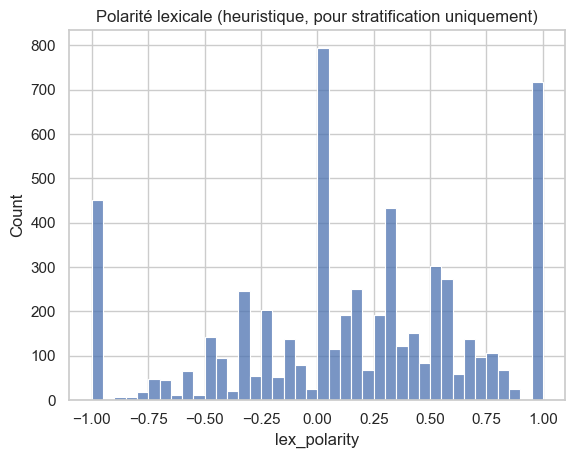

In [10]:
# À remplir après §6 : {question: {valeur_réponse: label}}
WEAK_MAP = {
    # "Did you have any emotions during the experience?": {"...": "..."},
}

NEG_LEX = ["terrif", "fear", "afraid", "hell", "demon", "dark", "void", "nothing", "alone", "torment", "scream", "panic", "evil",
           "peur", "terreur", "enfer", "démon", "noir", "néant", "vide", "seul", "tourment", "cri", "panique", "mal"]
POS_LEX = ["peace", "love", "light", "joy", "warm", "beautiful", "bliss", "calm", "welcom", "safe",
           "paix", "amour", "lumière", "joie", "chaleur", "beau", "béatitude", "calme", "accueil", "sécurité"]

def weak_from_qa(row):
    for q, mapping in WEAK_MAP.items():
        v = row.get(q)
        if isinstance(v, str):
            for k, lab in mapping.items():
                if k.lower() in v.lower(): return lab
    return None

def lex_score(text):
    t = text.lower()
    neg = sum(t.count(w) for w in NEG_LEX); pos = sum(t.count(w) for w in POS_LEX)
    return (pos - neg) / max(1, pos + neg), pos, neg

NOTE_MAP = [   # (regex sur la note éditoriale de l'index, label) — ordre = priorité
    (r"\b(void|nothingness|hellish|hell\b|distressing|frightening|terrif|fear)", "negative"),
    (r"\b(mixed|ambivalent)", "mixte"),
]
def weak_from_note(note):
    if not isinstance(note, str): return None
    for pat, lab in NOTE_MAP:
        if re.search(pat, note, re.I): return lab
    return None
df_full["weak_note"] = df_full.get("index_note", pd.Series(index=df_full.index, dtype=object)).map(weak_from_note)
print(df_full["weak_note"].value_counts(dropna=False))
df_full["weak_qa"] = df_full["self_valence_norm"].where(df_full["self_valence_norm"].isin(["positive", "mixte", "neutre", "negative"]))
lex = df_full.narrative.map(lex_score)
df_full["lex_polarity"] = lex.map(lambda x: x[0]); df_full["lex_pos"] = lex.map(lambda x: x[1]); df_full["lex_neg"] = lex.map(lambda x: x[2])
df_full["weak_lex"] = pd.cut(df_full.lex_polarity, [-1.01, -0.2, 0.2, 1.01], labels=["negative","mixte","positive"])
# Label faible final : valence déclarée > note éditoriale > lexique
df_full["weak_label"] = df_full["weak_qa"].fillna(df_full["weak_note"]).fillna(df_full["weak_lex"].astype(object))
print("Label faible final :"); print(df_full.weak_label.value_counts(dropna=False))
print("\nAccord valence déclarée vs heuristique lexicale (contrôle) :")
display(pd.crosstab(df_full["weak_qa"].fillna("—"), df_full["weak_lex"]))
sns.histplot(df_full.lex_polarity, bins=40); plt.title("Polarité lexicale (heuristique, pour stratification uniquement)"); plt.show()

## 8. Interface d'annotation manuelle
Deux dimensions, indépendantes :
- **Tonalité** : `positive` / `mixte` / `negative`, avec un **sous-type** qui dépend de la tonalité :
  - positive → `transcendante` (paix, lumière, unité, amour) · `relationnelle` (défunts, êtres, présence) · `cognitive` (revue de vie, savoir) · `observation` (sortie du corps calme, spectateur) · `autre`
  - negative (Bush & Greyson 2014) → `inversee` (contenu classique vécu avec terreur) · `vide` (néant, annihilation) · `infernale` · `autre`
  - mixte → `neg_vers_pos` · `pos_vers_neg` · `alterne_simultane` · `autre` (direction de la bascule)
- **Retentissement** : `apaisant` / `neutre` / `perturbant` — ce que l'expérience a laissé, indépendamment de son contenu.
Plus une **confiance** (1–3) et une note libre. Sauvegarde incrémentale dans `annotations.csv`, reprise automatique.

Échantillon stratifié sur `weak_lex` et la langue pour ne pas n'annoter que du positif.

In [51]:
import ipywidgets as w
from IPython.display import display, clear_output, HTML

N_SAMPLE = 250
SHOW_SELF_VALENCE = False     # masquer la valence déclarée pendant l'annotation (recommandé) ; True pour l'afficher
TRAIN_CATS = ["NDE", "Probable NDE", "Possible NDE", "NDE-Like", "FDE"]     # à ajuster : périmètre d'entraînement
pool = df_full[df_full["category"].isin(TRAIN_CATS) | df_full["category"].isna()]
# Sur-représente le négatif et le mixte, rares dans le corpus
weights = {"negative": 0.35, "mixte": 0.25, "neutre": 0.15, "positive": 0.25}
strata = pool.groupby("weak_label", observed=True)
sample_idx = []
for lab, g in strata:
    k = int(N_SAMPLE * weights.get(lab, 0.1))
    sample_idx += list(g.sample(min(k, len(g)), random_state=RNG).index)
sample_idx = sample_idx[:N_SAMPLE]
random.Random(RNG).shuffle(sample_idx)

done = pd.read_csv(ANNOT_CSV) if ANNOT_CSV.exists() else pd.DataFrame(columns=["idx","url","tonalite","sous_type","retentissement","confiance","note","ts"])
todo = [i for i in sample_idx if i not in set(done["idx"])]
print(f"Annoté : {len(done)} | Restant : {len(todo)}")

state = {"pos": 0}
out = w.Output()
ton = w.ToggleButtons(options=["positive","mixte","negative"], description="Tonalité")
SUBTYPES = {   # sous-types selon la tonalité (Bush & Greyson 2014 pour le négatif ; contenu dominant pour le positif ; direction de bascule pour le mixte)
    "positive": ["—", "transcendante", "relationnelle", "cognitive", "observation", "autre"],
    "negative": ["—", "inversee", "vide", "infernale", "observation", "autre"],
    "mixte":    ["—", "neg_vers_pos", "pos_vers_neg", "alterne_simultane", "autre"],
}
sub = w.ToggleButtons(options=SUBTYPES["positive"], description="Sous-type")
def on_ton_change(change):
    sub.options = SUBTYPES[change["new"]]; sub.value = "—"
ton.observe(on_ton_change, names="value")
ret = w.ToggleButtons(options=["apaisant","neutre","perturbant"], description="Retentissement")
conf = w.IntSlider(value=2, min=1, max=3, description="Confiance")
note = w.Text(description="Note", placeholder="optionnel", layout=w.Layout(width="70%"))
btn_save = w.Button(description="Enregistrer ▶", button_style="success")
btn_skip = w.Button(description="Passer", button_style="warning")

def render():
    with out:
        clear_output(wait=True)
        if state["pos"] >= len(todo):
            print("🎉 Échantillon terminé."); return
        i = todo[state["pos"]]
        r = df_full.loc[i]
        display(HTML(f"<b>{state['pos']+1}/{len(todo)}</b> — <i>{r.title}</i> — {r.get('category')} — lang={r.lang} — {r.n_chars} car."))
        ctx = "".join(f"<li><b>{k}</b> : {str(r.get(c))[:300]}</li>" for k, c in
                      ([("Valence déclarée", "self_valence")] if SHOW_SELF_VALENCE else []) + [("Émotions pendant", "emo_during"), ("Émotions après", "emo_after"),
                       ("Menace vitale", "life_threat"), ("Substances", "substances"), ("Note éditoriale", "index_note")] if isinstance(r.get(c), str))
        display(HTML(f"<ul style='font-size:90%;color:#444'>{ctx}</ul>"))
        display(HTML("<div style='white-space:pre-wrap;max-height:420px;overflow:auto;border:1px solid #ccc;padding:8px'>" + r.narrative + "</div>"))

def save(_):
    i = todo[state["pos"]]
    row = {"idx": i, "url": df_full.loc[i,"url"], "tonalite": ton.value,
           "sous_type": None if sub.value=="—" else sub.value, "retentissement": ret.value,
           "confiance": conf.value, "note": note.value, "ts": pd.Timestamp.now().isoformat()}
    pd.DataFrame([row]).to_csv(ANNOT_CSV, mode="a", header=not ANNOT_CSV.exists(), index=False)
    ton.value="positive"; sub.options = SUBTYPES["positive"]; sub.value="—"; ret.value="neutre"; conf.value=2; note.value=""
    state["pos"] += 1; render()

def skip(_):
    state["pos"] += 1; render()

btn_save.on_click(save); btn_skip.on_click(skip)
display(w.VBox([out, ton, sub, ret, conf, note, w.HBox([btn_save, btn_skip])]))
render()

Annoté : 100 | Restant : 148


## 9. Classifieur
Cible principale : `tonalite` (3 classes). Même code réutilisable pour `retentissement`.
- Baseline : TF-IDF (mots + bigrammes) + régression logistique.
- Embeddings : `paraphrase-multilingual-MiniLM-L12-v2` (FR+EN dans le même espace) + régression logistique.
- Validation croisée stratifiée, F1 macro, matrice de confusion. Modèle final sauvegardé (`joblib`).

In [52]:
"""
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import joblib

TARGET = "tonalite"    # ou "retentissement"
ann = pd.read_csv(ANNOT_CSV).drop_duplicates("idx", keep="last")
lab = ann.merge(df_full[["narrative","lang"]], left_on="idx", right_index=True)
lab = lab[lab.confiance >= 2]          # on écarte les annotations peu sûres
print(lab[TARGET].value_counts())
assert lab[TARGET].nunique() >= 2 and len(lab) >= 40, "Pas encore assez d'annotations pour entraîner."

X_text, y = lab.narrative.tolist(), lab[TARGET].values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

# --- Baseline TF-IDF ---
tfidf_clf = make_pipeline(TfidfVectorizer(ngram_range=(1,2), min_df=2, sublinear_tf=True, max_features=50000),
                          LogisticRegression(max_iter=2000, class_weight="balanced", C=2.0))
pred_tfidf = cross_val_predict(tfidf_clf, X_text, y, cv=cv)
print("TF-IDF + LR — F1 macro :", round(f1_score(y, pred_tfidf, average="macro"), 3))
print(classification_report(y, pred_tfidf))

# --- Embeddings multilingues ---
from sentence_transformers import SentenceTransformer
st = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
def embed(texts): return st.encode(texts, batch_size=32, show_progress_bar=True, normalize_embeddings=True)
E = embed(X_text)
emb_clf = LogisticRegression(max_iter=4000, class_weight="balanced", C=1.0)
pred_emb = cross_val_predict(emb_clf, E, y, cv=cv)
print("Embeddings + LR — F1 macro :", round(f1_score(y, pred_emb, average="macro"), 3))
print(classification_report(y, pred_emb))

labels = sorted(set(y))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, p, t in [(ax[0], pred_tfidf, "TF-IDF"), (ax[1], pred_emb, "Embeddings")]:
    sns.heatmap(confusion_matrix(y, p, labels=labels), annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=a)
    a.set_title(t); a.set_xlabel("prédit"); a.set_ylabel("vrai")
plt.tight_layout(); plt.show()

# Modèle final = le meilleur, entraîné sur tout
best = "emb" if f1_score(y, pred_emb, average="macro") >= f1_score(y, pred_tfidf, average="macro") else "tfidf"
if best == "emb": emb_clf.fit(E, y); joblib.dump({"kind":"emb","model":emb_clf,"st":"paraphrase-multilingual-MiniLM-L12-v2"}, DATA/f"clf_{TARGET}.joblib")
else: tfidf_clf.fit(X_text, y); joblib.dump({"kind":"tfidf","model":tfidf_clf}, DATA/f"clf_{TARGET}.joblib")
print("Modèle retenu :", best, "→", DATA/f"clf_{TARGET}.joblib")
"""

'\nfrom sklearn.feature_extraction.text import TfidfVectorizer\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.pipeline import make_pipeline\nfrom sklearn.model_selection import StratifiedKFold, cross_val_predict\nfrom sklearn.metrics import classification_report, confusion_matrix, f1_score\nimport joblib\n\nTARGET = "tonalite"    # ou "retentissement"\nann = pd.read_csv(ANNOT_CSV).drop_duplicates("idx", keep="last")\nlab = ann.merge(df_full[["narrative","lang"]], left_on="idx", right_index=True)\nlab = lab[lab.confiance >= 2]          # on écarte les annotations peu sûres\nprint(lab[TARGET].value_counts())\nassert lab[TARGET].nunique() >= 2 and len(lab) >= 40, "Pas encore assez d\'annotations pour entraîner."\n\nX_text, y = lab.narrative.tolist(), lab[TARGET].values\ncv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)\n\n# --- Baseline TF-IDF ---\ntfidf_clf = make_pipeline(TfidfVectorizer(ngram_range=(1,2), min_df=2, sublinear_tf=True, max_features=5000

## 10. Fightin' Words — vocabulaire distinctif par classe
Log-odds ratio avec prior de Dirichlet informatif (Monroe, Colaresi & Quinn 2008) : quels mots sont *significativement* sur-représentés dans les récits négatifs vs positifs, corrigé de la fréquence globale. Puis bigrammes et KWIC pour vérifier le contexte à la main.

In [53]:
"""
from sklearn.feature_extraction.text import CountVectorizer

STOP_FR = "le la les un une des de du et à au aux en dans que qui je j ai me ma mon mes il elle on nous vous ils elles ce cette ces se ne pas plus est était étais étaient sur pour avec comme tout tous très mais ou où par son sa ses leur y il n d l qu s".split()
STOP_EN = "the a an and of to in that i my me was were is it he she they we you this these those there with as for on at by be been being had have has not no but or so very just then when what which".split()
STOP = set(STOP_FR + STOP_EN)

def fightin_words(texts_a, texts_b, ngram=(1,1), min_df=3, alpha0=0.01, top=25, name_a="A", name_b="B"):
    cv = CountVectorizer(ngram_range=ngram, min_df=min_df, stop_words=list(STOP), lowercase=True)
    X = cv.fit_transform(list(texts_a) + list(texts_b))
    na = len(texts_a)
    ya = np.asarray(X[:na].sum(0)).ravel(); yb = np.asarray(X[na:].sum(0)).ravel()
    y_all = ya + yb; a0 = alpha0 * y_all.sum(); prior = a0 * y_all / y_all.sum()
    la = np.log((ya + prior) / (ya.sum() + a0 - ya - prior)); lb = np.log((yb + prior) / (yb.sum() + a0 - yb - prior))
    delta = la - lb; var = 1/(ya + prior) + 1/(yb + prior); z = delta / np.sqrt(var)
    vocab = np.array(cv.get_feature_names_out())
    res = pd.DataFrame({"term": vocab, "z": z, "n_a": ya, "n_b": yb}).sort_values("z")
    fig, ax = plt.subplots(figsize=(9, 7))
    plot = pd.concat([res.head(top), res.tail(top)])
    colors = ["#c0392b" if v < 0 else "#27ae60" for v in plot.z]
    ax.barh(plot.term, plot.z, color=colors); ax.axvline(0, color="k", lw=.8)
    ax.set_title(f"Mots distinctifs — vert : {name_a} | rouge : {name_b}  (z-score log-odds, prior Dirichlet)")
    plt.tight_layout(); plt.show()
    return res

lab_full = ann.merge(df_full, left_on="idx", right_index=True)
neg = lab_full[lab_full.tonalite=="negative"].narrative; pos = lab_full[lab_full.tonalite=="positive"].narrative
fw_uni = fightin_words(pos, neg, name_a="positive", name_b="negative")
fw_bi  = fightin_words(pos, neg, ngram=(2,2), min_df=2, top=20, name_a="positive", name_b="negative")

def kwic(term, texts, width=60, n=10):
    pat = re.compile(r".{0,%d}\b%s\b.{0,%d}" % (width, re.escape(term), width), re.I | re.S)
    hits = [m.group(0).replace("\n"," ") for t in texts for m in pat.finditer(t)]
    for h in hits[:n]: print("…" + h + "…")
    print(f"({len(hits)} occurrences)")

kwic("dark", neg)    # exemple — remplacer par les termes qui ressortent

# Prévalence des items de questionnaire par classe (si présents)
if qa_cols:
    for c in emo_q[:5]:
        display(pd.crosstab(lab_full["tonalite"], lab_full[c].fillna("n/a"), normalize="index").round(2))
        """

'\nfrom sklearn.feature_extraction.text import CountVectorizer\n\nSTOP_FR = "le la les un une des de du et à au aux en dans que qui je j ai me ma mon mes il elle on nous vous ils elles ce cette ces se ne pas plus est était étais étaient sur pour avec comme tout tous très mais ou où par son sa ses leur y il n d l qu s".split()\nSTOP_EN = "the a an and of to in that i my me was were is it he she they we you this these those there with as for on at by be been being had have has not no but or so very just then when what which".split()\nSTOP = set(STOP_FR + STOP_EN)\n\ndef fightin_words(texts_a, texts_b, ngram=(1,1), min_df=3, alpha0=0.01, top=25, name_a="A", name_b="B"):\n    cv = CountVectorizer(ngram_range=ngram, min_df=min_df, stop_words=list(STOP), lowercase=True)\n    X = cv.fit_transform(list(texts_a) + list(texts_b))\n    na = len(texts_a)\n    ya = np.asarray(X[:na].sum(0)).ravel(); yb = np.asarray(X[na:].sum(0)).ravel()\n    y_all = ya + yb; a0 = alpha0 * y_all.sum(); prior = a0 *

## 11. Application au corpus entier et export

In [54]:
"""
bundle = joblib.load(DATA/f"clf_{TARGET}.joblib")
texts_all = df_full.narrative.tolist()
if bundle["kind"] == "emb":
    E_all = embed(texts_all); proba = bundle["model"].predict_proba(E_all); pred = bundle["model"].classes_[proba.argmax(1)]
else:
    proba = bundle["model"].predict_proba(texts_all); pred = bundle["model"].classes_[proba.argmax(1)]
df_full[f"pred_{TARGET}"] = pred; df_full[f"pred_{TARGET}_conf"] = proba.max(1)

print(df_full[f"pred_{TARGET}"].value_counts(normalize=True).round(3))
sns.countplot(data=df_full, x=f"pred_{TARGET}", hue="lang"); plt.title("Répartition prédite sur le corpus entier"); plt.show()

# Fightin' words sur les prédictions (corpus entier) — à lire avec prudence : c'est du label prédit
_ = fightin_words(df_full[df_full[f"pred_{TARGET}"]=="positive"].narrative,
                  df_full[df_full[f"pred_{TARGET}"]=="negative"].narrative, name_a="positive (préd.)", name_b="negative (préd.)")

df_full.drop(columns=["raw_text"]).to_parquet(DATA/"corpus_labeled.parquet")
print("→", DATA/"corpus_labeled.parquet")
"""

'\nbundle = joblib.load(DATA/f"clf_{TARGET}.joblib")\ntexts_all = df_full.narrative.tolist()\nif bundle["kind"] == "emb":\n    E_all = embed(texts_all); proba = bundle["model"].predict_proba(E_all); pred = bundle["model"].classes_[proba.argmax(1)]\nelse:\n    proba = bundle["model"].predict_proba(texts_all); pred = bundle["model"].classes_[proba.argmax(1)]\ndf_full[f"pred_{TARGET}"] = pred; df_full[f"pred_{TARGET}_conf"] = proba.max(1)\n\nprint(df_full[f"pred_{TARGET}"].value_counts(normalize=True).round(3))\nsns.countplot(data=df_full, x=f"pred_{TARGET}", hue="lang"); plt.title("Répartition prédite sur le corpus entier"); plt.show()\n\n# Fightin\' words sur les prédictions (corpus entier) — à lire avec prudence : c\'est du label prédit\n_ = fightin_words(df_full[df_full[f"pred_{TARGET}"]=="positive"].narrative,\n                  df_full[df_full[f"pred_{TARGET}"]=="negative"].narrative, name_a="positive (préd.)", name_b="negative (préd.)")\n\ndf_full.drop(columns=["raw_text"]).to_parq

## 12. (optionnel) BERTopic — sous-types émergents
Décommenter si `bertopic` est installé (`pip install bertopic`). Utile pour voir si des familles de récits négatifs se dégagent sans supervision (vide / infernal / inversé…).

In [55]:
# from bertopic import BERTopic
# sub = df_full[df_full[f"pred_{TARGET}"]=="negative"].narrative.tolist()
# topic_model = BERTopic(embedding_model=st, language="multilingual", min_topic_size=8)
# topics, _ = topic_model.fit_transform(sub)
# display(topic_model.get_topic_info().head(15))
# topic_model.visualize_barchart(top_n_topics=8)

---
**Prochaine étape après ce notebook** : le fichier `clf_tonalite.joblib` s'applique tel quel à n'importe quel rappel libre (syncope de Liège, Dream2Image, rapports d'anesthésie). C'est ce qui rend la demande de données concrète.